<a href="https://colab.research.google.com/github/Ratludu/Backpack-Prediction-Challenge/blob/main/Backpack_Prices_Colad_LB_38.85278.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import locale
def getpreferredencoding(do_setlocale = True):
    return "UTF-8"
locale.getpreferredencoding = getpreferredencoding

In [2]:
from google.colab import userdata
import os
os.environ['KAGGLE_USERNAME'] = userdata.get('kaggleusername')
os.environ['KAGGLE_KEY'] = userdata.get('kaggleapi')

competition = 'playground-series-s5e2'

!kaggle competitions download -c {competition}

!unzip "{competition}.zip"

 98% 91.0M/92.7M [00:02<00:00, 43.2MB/s]
100% 92.7M/92.7M [00:02<00:00, 33.8MB/s]
Archive:  playground-series-s5e2.zip
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: train.csv               
  inflating: training_extra.csv      


In [3]:
!pip install dask-cuda==24.12.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.4/134.4 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.5/244.5 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.0/47.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.9 MB/s eta 0:00:00
  Attempting uninstall: dask
    Found existing installation: dask 2024.10.0
    Uninstalling dask-2024.10.0:
      Successfully uninstalled dask-2024.10.0


In [4]:
!git clone https://github.com/rapidsai/rapidsai-csp-utils.git
!python rapidsai-csp-utils/colab/pip-install.py

Cloning into 'rapidsai-csp-utils'...
remote: Enumerating objects: 577, done.
remote: Counting objects: 100% (143/143), done.
remote: Compressing objects: 100% (61/61), done.
remote: Total 577 (delta 116), reused 82 (delta 82), pack-reused 434 (from 3)
Receiving objects: 100% (577/577), 188.95 KiB | 5.40 MiB/s, done.
Resolving deltas: 100% (290/290), done.
Installing RAPIDS remaining 24.12.* libraries
Using Python 3.11.11 environment at /usr
Resolved 154 packages in 3.21s
Prepared 21 packages in 49.32s
Uninstalled 1 package in 120ms
Installed 21 packages in 106ms
 + cucim-cu12==24.12.0
 + cugraph-cu12==24.12.0
 + cuml-cu12==24.12.0
 + cuproj-cu12==24.12.0
 + cuspatial-cu12==24.12.0
 + cuvs-cu12==24.12.0
 + cuxfilter-cu12==24.12.0
 + dask-cudf-cu12==24.12.0
 + datashader==0.17.0
 + distributed-ucxx-cu12==0.41.0
 + jupyter-server-proxy==4.4.0
 + libcuspatial-cu12==24.12.0
 + libucx-cu12==1.17.0.post1
 + libucxx-cu12==0.41.0
 + pyct==0.5.0
 + raft-dask-cu12==24.12.0
 - scikit-image==0.25.1

In [5]:
!pip install catboost
!pip install optuna
!pip install scikit-learn
!pip install numpy
!pip install seaborn
!pip install matplotlib
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.4/383.4 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.6/233.6 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 7.7 MB/s eta 0:00:00


In [6]:
import pandas as pd
import numpy as np
from numpy import random
from cuml.preprocessing import TargetEncoder
from catboost import CatBoostRegressor
from sklearn.model_selection import cross_validate, cross_val_predict
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

In [16]:
class config:
    # data links
    train_link = "train.csv"
    train_ex_link = "training_extra.csv"
    test_link = "test.csv"
    sub_link = "sample_submission.csv"

    # create folds config

    n_splits = 25

    # Ignore Columns

    col_ignore = ["id", "Price"]
    num_cols = ["Weight Capacity (kg)"]
    # target

    submit = True

    target = "Price"

    add_original = False

In [8]:
def rmse(y_true, y_pred):
    error = 0

    for yt, yp in zip(y_true, y_pred):
        error += (yt - yp) ** 2

    m = np.sqrt(error / len(y_true))

    return m

In [9]:
def random_columns(columns):

  # Generate random number for how many columns we want to concat
  rand_num = np.random.randint(2,5)

  # choose the columns from the list of columns with no repeats
  rand_cols = []
  for i in range(rand_num):
    col = np.random.choice(columns)
    while col in rand_cols:
      col = np.random.choice(columns)
    rand_cols.append(col)

  # return a list of the columns

  return "-".join(col for col in rand_cols),rand_cols


In [17]:
train = pd.read_csv(config.train_link)
train_ex = pd.read_csv(config.train_ex_link)
test = pd.read_csv(config.test_link)

In [18]:
train = pd.concat([train,train_ex], axis = 0, ignore_index = True)

In [19]:
kf = KFold(n_splits = config.n_splits, shuffle = True, random_state = 42)

drop = ['Brand', 'Material', 'Size', 'Compartments', 'Laptop Compartment', 'Color', 'Waterproof']
added_fe = ['size-laptop compartment_fe']
oof = np.zeros(len(train))
preds = np.zeros(len(test))
features = [col for col in train.columns if col not in config.col_ignore]
cats = [col for col in features if col not in config.num_cols]
cats.extend(added_fe)
m = []
for fold, (train_idx, test_idx) in enumerate(kf.split(train)):

    x_train, x_val = train.loc[train_idx, features].copy(), train.loc[test_idx, features].copy()
    y_train, y_val = train.loc[train_idx, config.target].copy(), train.loc[test_idx, config.target].copy()
    x_test = test[features].copy()

    TE = TargetEncoder(n_folds=27, smooth=21, split_method = 'random', stat = 'mean')


    # adding extra features

    x_train["size-laptop compartment_fe"] = x_train['Size'].astype('str')+x_train['Laptop Compartment'].astype('str')
    x_val["size-laptop compartment_fe"] = x_val['Size'].astype('str')+x_val['Laptop Compartment'].astype('str')
    x_test["size-laptop compartment_fe"] = x_test['Size'].astype('str')+x_test['Laptop Compartment'].astype('str')

    for col in added_fe:
      TE.fit(x_train[col], y_train)
      x_train[f'{col}_TE'] = TE.transform(x_train[col])
      x_val[f'{col}_TE'] = TE.transform(x_val[col])
      x_test[f'{col}_TE'] = TE.transform(x_test[col])

    for col in features:
        TE.fit(x_train[col], y_train)
        x_train[f'{col}_TE'] = TE.transform(x_train[col])
        x_val[f'{col}_TE'] = TE.transform(x_val[col])
        x_test[f'{col}_TE'] = TE.transform(x_test[col])

    x_train["colorxweight"] = x_train['Color_TE']*x_train['Weight Capacity (kg)_TE']
    x_val["colorxweight"] = x_val['Color_TE']*x_val['Weight Capacity (kg)_TE']
    x_test["colorxweight"] = x_test['Color_TE']*x_test['Weight Capacity (kg)_TE']

    x_train["Sizexweight"] = x_train['Size_TE']*x_train['Weight Capacity (kg)_TE']
    x_val["Sizexweight"] = x_val['Size_TE']*x_val['Weight Capacity (kg)_TE']
    x_test["Sizexweight"] = x_test['Size_TE']*x_test['Weight Capacity (kg)_TE']

    x_train["Sizexbrand"] = x_train['Size_TE']*x_train['Brand_TE']
    x_val["Sizexbrand"] = x_val['Size_TE']*x_val['Brand_TE']
    x_test["Sizexbrand"] = x_test['Size_TE']*x_test['Brand_TE']

    x_train["Materialxweight"] = x_train['Material_TE']*x_train['Weight Capacity (kg)_TE']
    x_val["Materialxweight"] = x_val['Material_TE']*x_val['Weight Capacity (kg)_TE']
    x_test["Materialxweight"] = x_test['Material_TE']*x_test['Weight Capacity (kg)_TE']

    for cat in cats:
        x_train[cat] =  x_train[cat].fillna("MISSING")
        x_val[cat] = x_val[cat].fillna("MISSING")
        x_test[cat] = x_test[cat].fillna("MISSING")
        x_train[cat] =  x_train[cat].astype('str')
        x_val[cat] = x_val[cat].astype('str')
        x_test[cat] = x_test[cat].astype('str')

    print(x_train.columns)

    model = CatBoostRegressor(task_type = "GPU",
                              grow_policy = 'Lossguide',
                              random_state = 42,
                              cat_features = cats,
                              verbose = 250,
                              loss_function='RMSE')

    model.fit(x_train, y_train)

    val_preds = model.predict(x_val)

    oof[test_idx] = val_preds

    preds += model.predict(x_test)/config.n_splits

    score = rmse(y_val, val_preds)

    m.append(score)

    print(f'Fold: {fold+1}, Score: {score}')

print(f"The average CV is {np.average(m)}")

Index(['Brand', 'Material', 'Size', 'Compartments', 'Laptop Compartment',
       'Waterproof', 'Style', 'Color', 'Weight Capacity (kg)',
       'size-laptop compartment_fe', 'size-laptop compartment_fe_TE',
       'Brand_TE', 'Material_TE', 'Size_TE', 'Compartments_TE',
       'Laptop Compartment_TE', 'Waterproof_TE', 'Style_TE', 'Color_TE',
       'Weight Capacity (kg)_TE', 'colorxweight', 'Sizexweight', 'Sizexbrand',
       'Materialxweight'],
      dtype='object')
Learning rate set to 0.119064
0:	learn: 38.8853512	total: 83ms	remaining: 1m 22s
250:	learn: 38.6268362	total: 15.4s	remaining: 45.8s
500:	learn: 38.5999230	total: 30.5s	remaining: 30.4s
750:	learn: 38.5753967	total: 44.9s	remaining: 14.9s
999:	learn: 38.5528446	total: 59.3s	remaining: 0us
Fold: 1, Score: 38.64186299081143
Index(['Brand', 'Material', 'Size', 'Compartments', 'Laptop Compartment',
       'Waterproof', 'Style', 'Color', 'Weight Capacity (kg)',
       'size-laptop compartment_fe', 'size-laptop compartment_fe_T

In [ ]:
save_columns ={}
save_score = {}

added_fe = ['size-laptop compartment_fe']
for trial in range(10):

  features = [col for col in train.columns if col not in config.col_ignore]
  cats = [col for col in features if col not in config.num_cols]
  cats.extend(added_fe)

  randf,randc = random_columns(features)

  print(f"Trial {trial +1}: {randc}")

  kf = KFold(n_splits = 5, shuffle = True, random_state = 42)

  oof = np.zeros(len(train))
  preds = np.zeros(len(test))
  cats.append(randf)
  m = []
  for fold, (train_idx, test_idx) in enumerate(kf.split(train)):

      x_train, x_val = train.loc[train_idx, features].copy(), train.loc[test_idx, features].copy()
      y_train, y_val = train.loc[train_idx, config.target].copy(), train.loc[test_idx, config.target].copy()
      x_test = test[features].copy()

      TE = TargetEncoder(n_folds=27, smooth=21, split_method = 'random', stat = 'mean')


      # adding extra features

      x_train["size-laptop compartment_fe"] = x_train['Size'].astype('str')+x_train['Laptop Compartment'].astype('str')
      x_val["size-laptop compartment_fe"] = x_val['Size'].astype('str')+x_val['Laptop Compartment'].astype('str')
      x_test["size-laptop compartment_fe"] = x_test['Size'].astype('str')+x_test['Laptop Compartment'].astype('str')

      for col in added_fe:
        TE.fit(x_train[col], y_train)
        x_train[f'{col}_TE'] = TE.transform(x_train[col])
        x_val[f'{col}_TE'] = TE.transform(x_val[col])
        x_test[f'{col}_TE'] = TE.transform(x_test[col])

      # random features

      x_train[randf] = "FE_"
      x_val[randf] = "FE_"
      x_test[randf] = "FE_"

      for col in randc:
          x_train[randf] += x_train[col].astype('str')
          x_val[randf] += x_val[col].astype('str')
          x_test[randf] += x_test[col].astype('str')

      TE.fit(x_train[randf], y_train)
      x_train[f'{randf}_TE'] = TE.transform(x_train[randf])
      x_val[f'{randf}_TE'] = TE.transform(x_val[randf])
      x_test[f'{randf}_TE'] = TE.transform(x_test[randf])

      for col in features:
          TE.fit(x_train[col], y_train)
          x_train[f'{col}_TE'] = TE.transform(x_train[col])
          x_val[f'{col}_TE'] = TE.transform(x_val[col])
          x_test[f'{col}_TE'] = TE.transform(x_test[col])


      x_train["colorxweight"] = x_train['Color_TE']*x_train['Weight Capacity (kg)_TE']
      x_val["colorxweight"] = x_val['Color_TE']*x_val['Weight Capacity (kg)_TE']
      x_test["colorxweight"] = x_test['Color_TE']*x_test['Weight Capacity (kg)_TE']

      x_train["Sizexweight"] = x_train['Size_TE']*x_train['Weight Capacity (kg)_TE']
      x_val["Sizexweight"] = x_val['Size_TE']*x_val['Weight Capacity (kg)_TE']
      x_test["Sizexweight"] = x_test['Size_TE']*x_test['Weight Capacity (kg)_TE']

      x_train["Sizexbrand"] = x_train['Size_TE']*x_train['Brand_TE']
      x_val["Sizexbrand"] = x_val['Size_TE']*x_val['Brand_TE']
      x_test["Sizexbrand"] = x_test['Size_TE']*x_test['Brand_TE']

      x_train["Materialxweight"] = x_train['Material_TE']*x_train['Weight Capacity (kg)_TE']
      x_val["Materialxweight"] = x_val['Material_TE']*x_val['Weight Capacity (kg)_TE']
      x_test["Materialxweight"] = x_test['Material_TE']*x_test['Weight Capacity (kg)_TE']

      for cat in cats:
          x_train[cat] =  x_train[cat].fillna("MISSING")
          x_val[cat] = x_val[cat].fillna("MISSING")
          x_test[cat] = x_test[cat].fillna("MISSING")
          x_train[cat] =  x_train[cat].astype('str')
          x_val[cat] = x_val[cat].astype('str')
          x_test[cat] = x_test[cat].astype('str')

      model = CatBoostRegressor(task_type = "GPU",
                                grow_policy = 'Lossguide',
                                random_state = 42,
                                cat_features = cats,
                                verbose = 250,
                                loss_function='RMSE')

      model.fit(x_train, y_train)

      val_preds = model.predict(x_val)

      oof[test_idx] = val_preds

      preds += model.predict(x_test)/config.n_splits

      score = rmse(y_val, val_preds)

      m.append(score)

      print(f'Fold: {fold+1}, Score: {score}')

  print(f"The average CV is {np.average(m)}, with {randf}")
  cats.pop()

  save_columns[randf] = randc
  save_score[randf] = np.average(m)


Trial 1: ['Laptop Compartment', 'Size', 'Compartments', 'Color']
Learning rate set to 0.116254
0:	learn: 38.8946020	total: 69.8ms	remaining: 1m 9s
250:	learn: 38.6387200	total: 14.2s	remaining: 42.5s
500:	learn: 38.6058404	total: 27.3s	remaining: 27.2s
750:	learn: 38.5769515	total: 36.4s	remaining: 12.1s
999:	learn: 38.5491881	total: 49.2s	remaining: 0us
Fold: 1, Score: 38.65392741225563
Learning rate set to 0.116254
0:	learn: 38.8963013	total: 68.5ms	remaining: 1m 8s
250:	learn: 38.6409260	total: 14s	remaining: 41.7s
500:	learn: 38.6105425	total: 24s	remaining: 23.9s
750:	learn: 38.5818543	total: 36.2s	remaining: 12s
999:	learn: 38.5561890	total: 49s	remaining: 0us


In [16]:
save_score

{'Color-Waterproof-Weight Capacity (kg)': 38.67291807480242,
 'Size-Laptop Compartment': 38.67265209539438,
 'Compartments-Material': 38.67369692179007,
 'Material-Waterproof-Brand-Weight Capacity (kg)': 38.67270661382077,
 'Laptop Compartment-Size-Brand-Waterproof': 38.67290665442921,
 'Compartments-Color-Material': 38.67525352509695,
 'Style-Material-Brand': 38.67400701743156,
 'Weight Capacity (kg)-Brand-Style-Laptop Compartment': 38.67350157775205,
 'Compartments-Waterproof-Laptop Compartment': 38.673421588741824,
 'Material-Size-Laptop Compartment-Compartments': 38.6737535948627}

<Axes: >

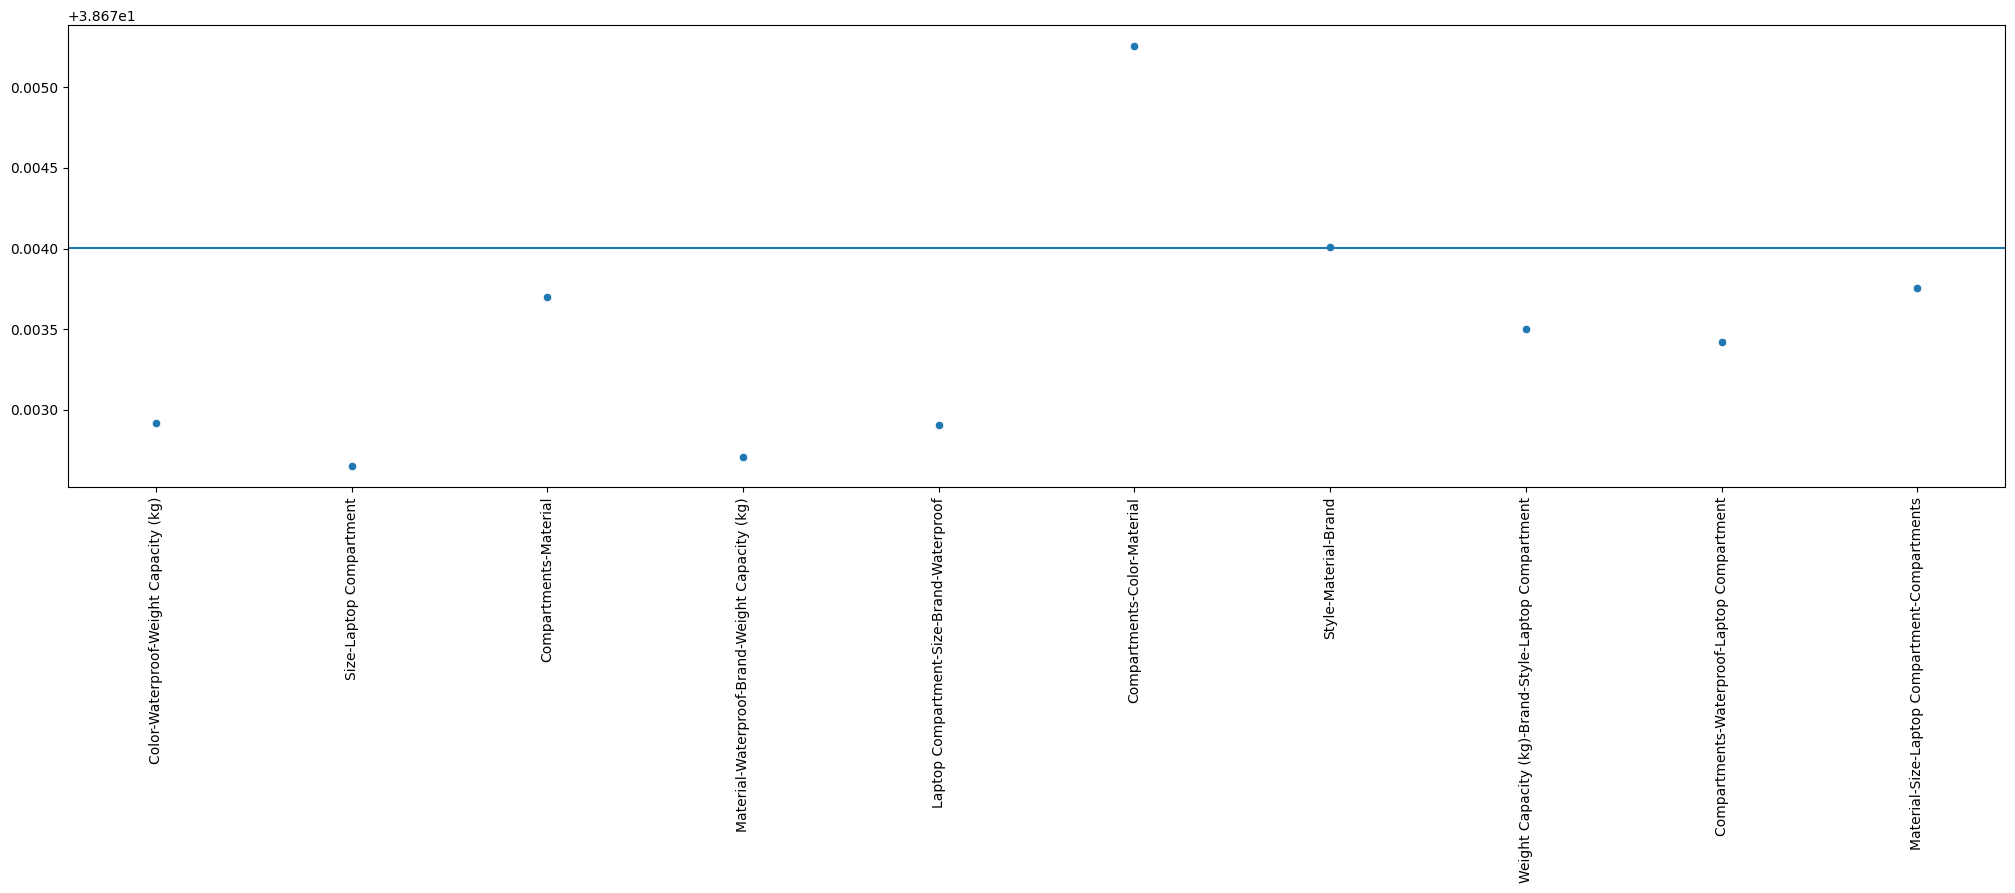

In [17]:
# plot the scores
keys = list(save_score.keys())
values = list(save_score.values())

plt.figure(figsize=(25, 6))
plt.xticks(rotation=90)
plt.axhline(y=38.67265209539438)
sns.scatterplot(x = keys, y =values)

In [20]:
submission = pd.read_csv(config.sub_link)
submission[config.target] = preds
submission.to_csv("submission.csv", index = False)

submission

,id,Price
0,300000,82.430495
1,300001,82.641218
2,300002,91.118955
3,300003,77.930937
4,300004,79.317770
...,...,...
199995,499995,82.257425
199996,499996,71.863275
199997,499997,82.754860
199998,499998,82.135725


In [ ]:
drop = ['Brand', 'Material', 'Size', 'Compartments', 'Laptop Compartment', 'Color', 'Waterproof']

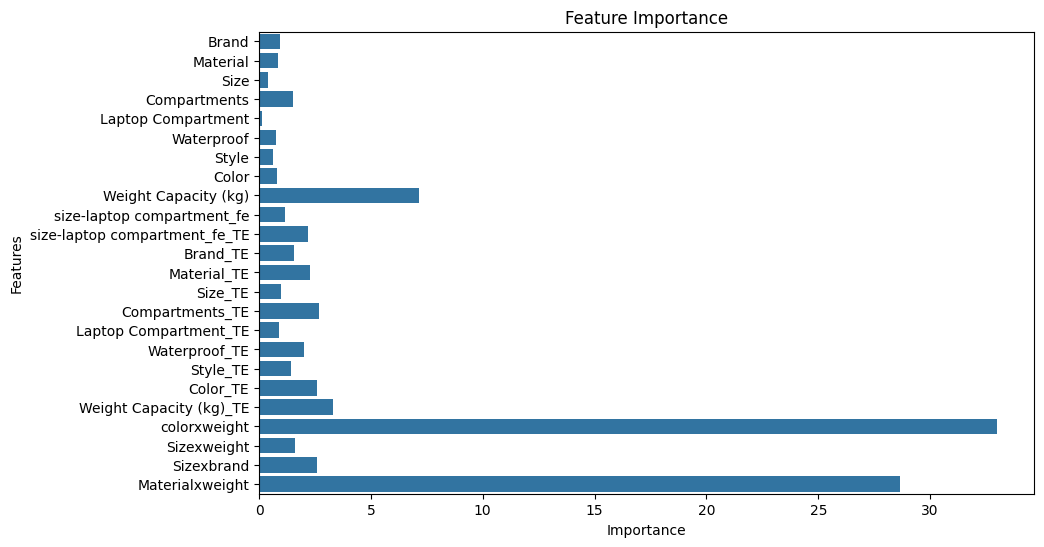

In [22]:
plt.figure(figsize=(10, 6))
sns.barplot(x=model.get_feature_importance(), y=x_train.columns)
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()

In [21]:
if config.submit:
  !kaggle competitions submit -c {competition} -f submission.csv -m 'Submission with 20 kfold TE combo'

100% 4.74M/4.74M [00:01<00:00, 3.98MB/s]
Successfully submitted to Backpack Prediction Challenge

In [ ]:
!kaggle competitions submissions -c {competition}

fileName        date                 description                                         status    publicScore  privateScore  
--------------  -------------------  --------------------------------------------------  --------  -----------  ------------  
submission.csv  2025-02-08 00:45:22  Submission with 20 kfold TE combo                   pending                              
submission.csv  2025-02-08 00:06:03  Submission with 20 kfold TE combo                   complete  38.85639                   
submission.csv  2025-02-07 05:46:15  Notebook 10 folds Backpack Prediction  | Version 2  complete  38.85514                   
submission.csv  2025-02-07 04:56:39  Notebook 10 folds Backpack Prediction  | Version 1  complete  38.85598                   
submission.csv  2025-02-07 04:27:10  Notebook Fork of Backpack Prediction  | Version 5   complete  38.85840                   
submission.csv  2025-02-07 04:10:02  Notebook Fork of Backpack Prediction  | Version 4   complete  38.85656    